# Simulating iceberg "Juliette"

In [1]:
#Imports
import pandas as pd
import xarray as xr
import numpy as np
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader    
from datetime import datetime,timedelta, timezone

In [2]:
#Define additional functions
def calc_iceberg_size(iceberg_in1):
    '''Correct iceberg size not supplied with empirical relations before seeding iceberg.
    '''
    lengths = np.array(iceberg_in1['length'])
    if 'length' in iceberg_in1 and 'width' not in iceberg_in1:
        iceberg_in1['width'] = 0.7*lengths*np.exp(-0.00062*lengths)
    if 'length' in iceberg_in1 and np.logical_or('draft' not in iceberg_in1,'sail' not in iceberg_in1):
        rho_i, rho_w = 900,1027 #kg/m3
        height = np.array(0.4*lengths*np.exp(-0.00062*lengths))
        if np.logical_and('draft' not in iceberg_in1, 'sail' in iceberg_in1): print('Implement')
        elif np.logical_and('draft' not in iceberg_in1, 'sail' not in iceberg_in1): draft = height*(rho_i/rho_w)
        if np.logical_and('sail' not in iceberg_in1, 'draft' not in iceberg_in1): sail = height*(1-rho_i/rho_w) 
        elif np.logical_and('sail' not in iceberg_in1, 'draft' in iceberg_in1): print('Implement')
        iceberg_in1['draft'] = draft
        iceberg_in1['sail'] = sail
    return iceberg_in1

In [3]:
#Read and subset tracker data
df = pd.read_csv('../input/Osker-X2.csv', sep=';') #ADAPT
df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
ds = xr.Dataset.from_dataframe(df)
ds_daily = ds.groupby("time.date").first() #Daily subset
ds_3day = ds_daily.isel(date=slice(0, None, 3)) #3-daily subset

In [4]:
#Define index of initial simulation time steps
idx = np.arange(ds_3day.lat.size) #here, 3-dayly throughout observed trajectory
print(idx)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [5]:
#Dictionary of available input data
env={'topaz4': 'cmems_mod_arc_phy_my_topaz4_P1D-m',
     'topaz4_ensemble':'https://thredds.met.no/thredds/dodsC/accibergt42/topaz4_be_mem010.ncml',#'https://thredds.met.no/thredds/catalog/accibergt42/catalog.html',
            'topaz5': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',
            'topaz5_ensemble': 'https://thredds.met.no/thredds/catalog/accibergt5/catalog.html',
            'topaz6': '',
            'glophyanfc': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m', #Global anfc (mercator)
            'glorys': 'cmems_mod_glo_phy_my_0.083deg_P1D-m',
            'wind_glophyre':'cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H', #2007-2026
            'wind_glophynrt':'cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H', #2024-2026
            'era5':'../input/era5_juliette.nc'} #Has to be downloaded

Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 25.24it/s]
INFO - 2026-05-12T15:53:50Z - Selected dataset version: "202506"
INFO - 2026-05-12T15:53:50Z - Selected dataset part: "default"
Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 33.35it/s]
INFO - 2026-05-12T15:53:51Z - Selected dataset version: "202207"
INFO - 2026-05-12T15:53:51Z - Selected dataset part: "default"
WARNING - 2026-05-12T15:53:51Z - The dataset cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H, version '202207', part 'default' is currently being updated. Data after 2026-05-11T00:00:00.000Z may not be up to date.


<xarray.Dataset> Size: 32MB
Dimensions:                                   (trajectory: 110, time: 1729)
Coordinates:
  * trajectory                                (trajectory) int32 440B 0 ... 109
  * time                                      (time) datetime64[ns] 14kB 2025...
Data variables: (12/39)
    status                                    (trajectory, time) float64 2MB ...
    moving                                    (trajectory, time) float64 2MB ...
    age_seconds                               (trajectory, time) float32 761kB ...
    origin_marker                             (trajectory, time) float64 2MB ...
    lon                                       (trajectory, time) float32 761kB ...
    lat                                       (trajectory, time) float32 761kB ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 761kB ...
    sea_ice_area_fraction                     (trajectory, time) float32 761kB ...
    sea_ice_thickness                         (trajectory, time) float32 761kB ...
    sea_ice_x_velocity                        (trajectory, time) float32 761kB ...
    sea_ice_y_velocity                        (trajectory, time) float32 761kB ...
    land_binary_mask                          (trajectory, time) float32 761kB ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               nan
    geospatial_vertical_max:                                               nan
    geospatial_vertical_positive:                                          up

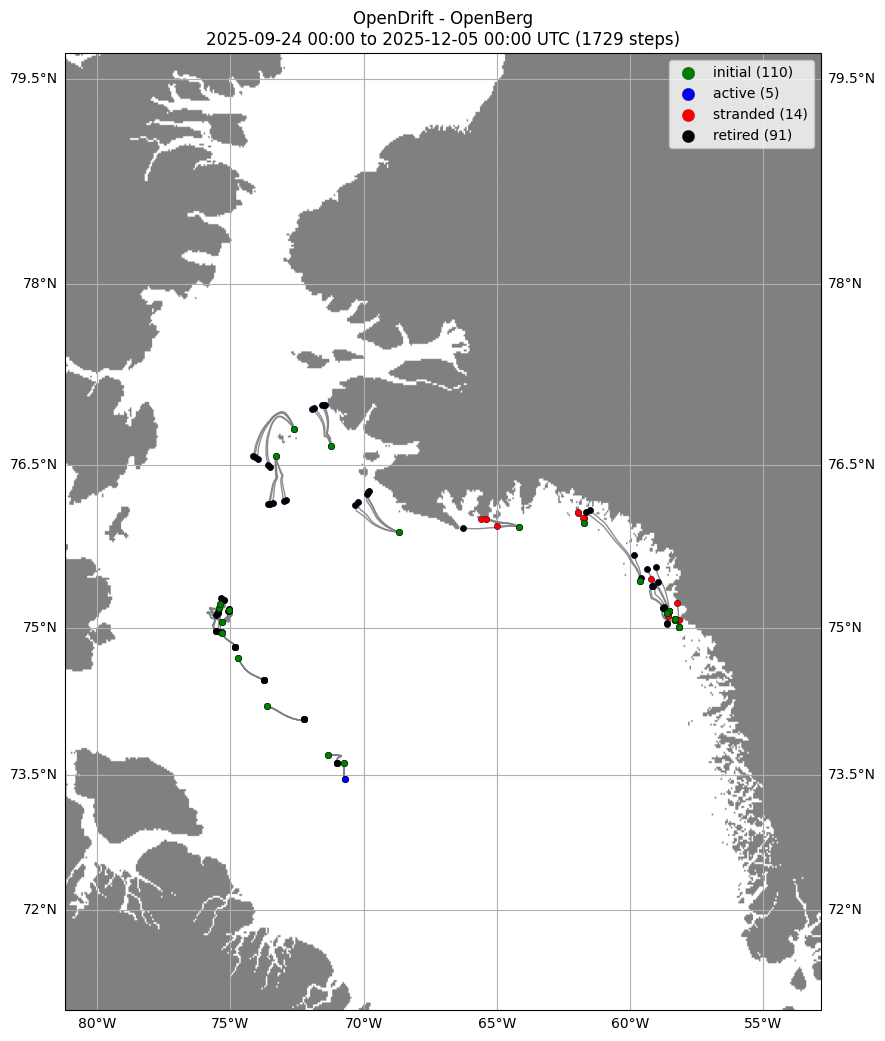

In [14]:
wvals = env['wind_glophynrt'] #choose wind input
lons, lats, times = ds_3day.lon[idx],ds_3day.lat[idx],[t.values.astype(datetime) for t in ds_3day.time[idx]]

#for input_l in [[ovals,wvals] for oname,ovals in env.items() if 'wind' not in oname]: #Loops thorugh the ocean input
for input_l in [[env['topaz4'],wvals],]:
    oname='topaz4_windglophynrt'
    #Information that are similar (or varied similarely) for every initialisation. 
    n=5 #number of icebergs released on every initialisation
    randspace=np.random.rand(n)
    #iceberg = {'length':150+randspace*100,'width':80+randspace*10, 
     #       'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1}
    iceberg = {'length':[50,100,500,1000,2000], 
           'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1}
    iceberg = calc_iceberg_size(iceberg) #this function adds missing iceberg sizes
    #iceberg = {'length':[50,500,1000],'width':[50,500,1000],'draft':[5,10,10],'sail':[0.5,1,1],'water_form_drag_coef':[0.25,0.9,1.5],'wind_form_drag_coef':[0.5,1.3,1.5]}#Initial conditions varied similarely for every position
    #iceberg = {'length':[150,200,250],'width':[80,85,90],'water_form_drag_coef':[0.25,0.6,0.9,1.5],'wind_form_drag_coef':[0.5,0.7,1.3,1.5]}#Initial conditions varied similarely for every position
    #simulation
    o=OpenBerg(loglevel=20,logfile='../results/out.log')
    o.set_config('drift:max_age_seconds', 3600*24*3) #Terminates simulations 3 days after their individual initialisation
    #o.set_config('drift:vertical_profile',True)
    o.add_readers_from_list(input_l) 
    for lon, lat, time in zip(lons, lats, times): #Loops through initialisations of time-positions
        o.seed_elements(lon=lon, lat=lat, time=time, number=n, radius=0, **iceberg)
    oi = o.run(duration=timedelta(days=int(idx.size*3)), #duration from first initialisation to last termination
               outfile='../results/juliette_%s_specialsizes2.nc'%oname)
    o.plot(fast=True,filename='../results/juliette_map_%s_specialsizes2.png'%oname)
oi

In [7]:
#o.plot(fast=True,filename='../results/juliette_map.png')

In [8]:
#np.mean(np.any(oi.status==1,axis=1)) #percentage of trajectories that became stranded (at any time)
#np.mean(np.any(oi.status==2,axis=1)) #percentage of trajectories that meltet
#oi.sail[np.any(oi.status==2,axis=1),0].values #which size do melted trajectories have??

<xarray.DataArray 'status' ()> Size: 8B
array(0.)
Attributes:
    valid_range:    [0 2]
    flag_values:    [0 1 2]
    flag_meanings:  active stranded retired

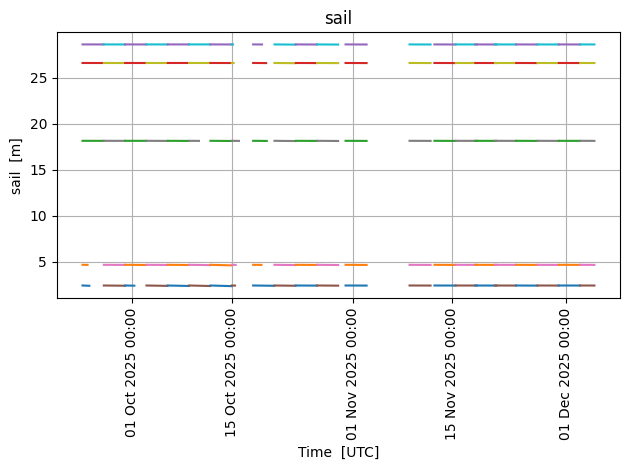

In [9]:
o.plot_property('sail')#,filename='../results/juliette_topaz4.png')

NOtes from evevning of 12 may (TUE)
- iceberg size varied (L=50 to 2000, other empirical): only changes drift angle for most iniialisations, not distance (for surfcurrent)
- vertical profile of current makes it only shorter
- size difference no impact when in sea ice,
also:
- wind is important here (when i fogot it much shorter distance)
- ensemble members of topaz4 and 5 need to merged before and supplied -->test

Hi Mohamed,
After our talk today, I tried to play around a little bit more with the initial size of Juliette and I found that the size mostly influences the drift directions, not distance (see plot). I used unreasonably large and small sizes (50 to 2000m). Using the vertical profile of the currents (so far only surface currents used) made the trajectories significanytly shorter. Interesstingly the size difference has little effect in the time with sea ice.
In the last round of simulations I varied drag coefficients and it did not seem to have a large impact. 
What had a large impact is wind. When i switched the wind off the trajectories where much shorter. There is a minor difference between when using the two wind products available on cmems. I will try out era5 tomorrow. This might indicate that we need waves (also to be tried out tomorrow).

Cheers, Lia